In [ ]:
# Cluster Visualization & Silhouette Score

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

plt.rcParams['figure.figsize'] = (7,5)
sns.set_style("whitegrid")
np.random.seed(42)

In [2]:
# Load Data

X_blob, y_blob_true = make_blobs(n_samples=500, centers=4, cluster_std=0.9, random_state=42)

iris = load_iris()
X_iris = iris.data
feature_names = iris.feature_names
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


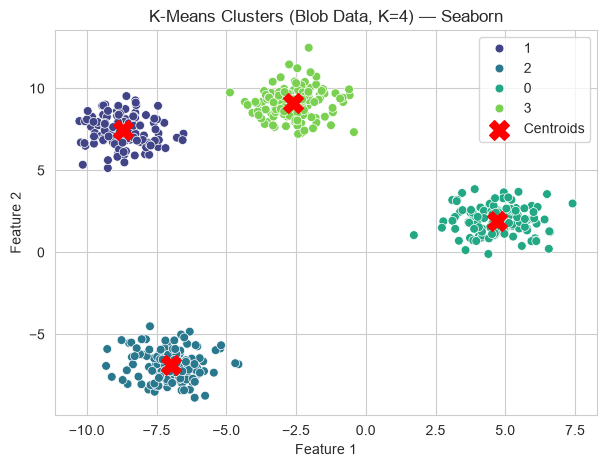

In [3]:
# Seaborn Cluster Visualization
# leaner, styled scatter plots using seaborn instead of raw matplotlib.

kmeans_blob = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_blob = kmeans_blob.fit_predict(X_blob)

df_blob = pd.DataFrame(X_blob, columns=['Feature 1', 'Feature 2'])
df_blob['Cluster'] = labels_blob.astype(str)

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_blob, x='Feature 1', y='Feature 2', hue='Cluster', palette='viridis', s=40)
plt.scatter(kmeans_blob.cluster_centers_[:,0], kmeans_blob.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clusters (Blob Data, K=4) — Seaborn")
plt.legend()
plt.show()

c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


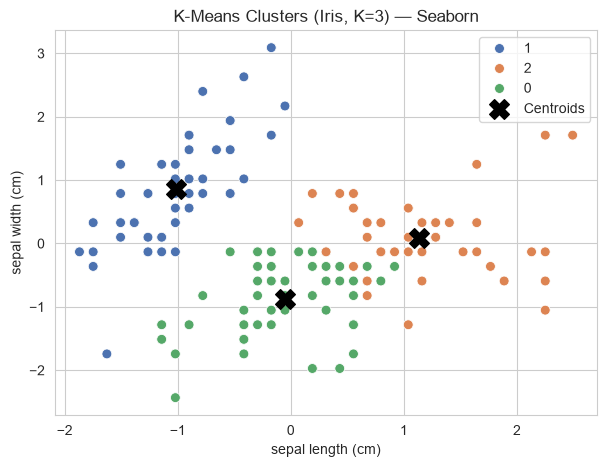

In [4]:
kmeans_iris = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_iris = kmeans_iris.fit_predict(X_iris_scaled)

df_iris_plot = pd.DataFrame(X_iris_scaled[:, :2], columns=[feature_names[0], feature_names[1]])
df_iris_plot['Cluster'] = labels_iris.astype(str)

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_iris_plot, x=feature_names[0], y=feature_names[1], hue='Cluster', palette='deep', s=50)
plt.scatter(kmeans_iris.cluster_centers_[:,0], kmeans_iris.cluster_centers_[:,1],
            c='black', marker='X', s=200, label='Centroids')
plt.title("K-Means Clusters (Iris, K=3) — Seaborn")
plt.legend()
plt.show()

c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\sit

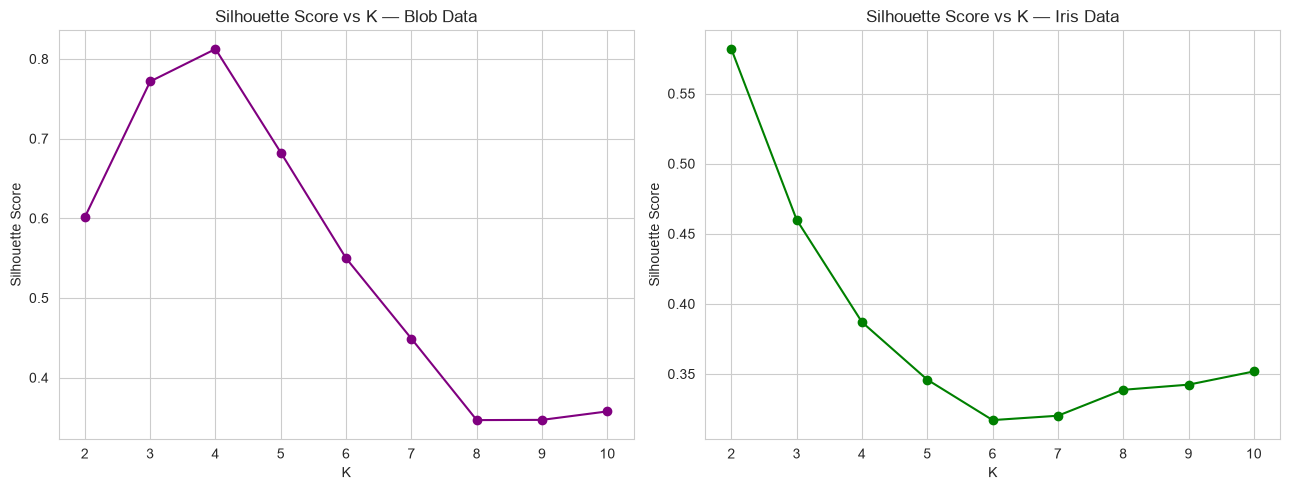

Best K (blob) by silhouette: 4
Best K (iris) by silhouette: 2


In [5]:
# Silhouette Score Across K (validates elbow choice)

def silhouette_across_k(X, k_range):
    scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        scores.append(silhouette_score(X, labels))
    return scores

k_range = range(2, 11)  # silhouette undefined for K=1
sil_blob = silhouette_across_k(X_blob, k_range)
sil_iris = silhouette_across_k(X_iris_scaled, k_range)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(list(k_range), sil_blob, marker='o', color='purple')
axes[0].set_title("Silhouette Score vs K — Blob Data")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Silhouette Score")

axes[1].plot(list(k_range), sil_iris, marker='o', color='green')
axes[1].set_title("Silhouette Score vs K — Iris Data")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

print("Best K (blob) by silhouette:", list(k_range)[int(np.argmax(sil_blob))])
print("Best K (iris) by silhouette:", list(k_range)[int(np.argmax(sil_iris))])

c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


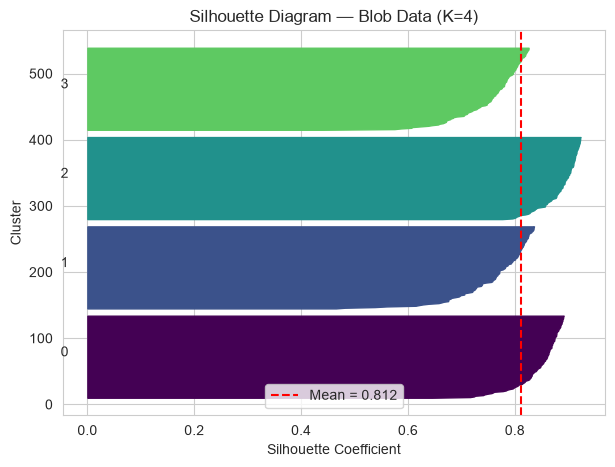

c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


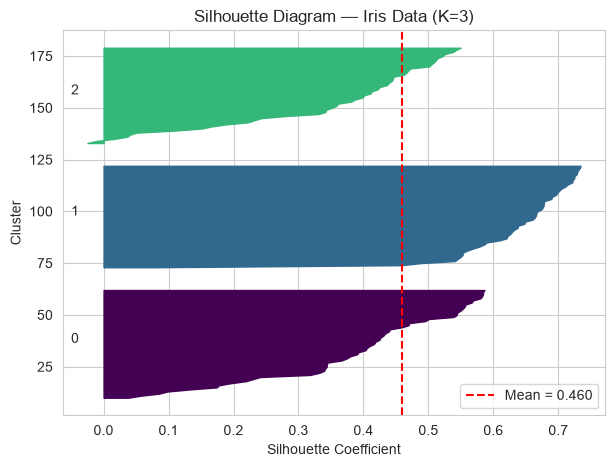

In [6]:
# Per-Sample Silhouette Plot (diagnostic)

def plot_silhouette_diagram(X, k, title):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_vals = silhouette_samples(X, labels)
    avg_score = silhouette_score(X, labels)

    fig, ax = plt.subplots(figsize=(7,5))
    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(sil_vals[labels == i])
        size = cluster_vals.shape[0]
        y_upper = y_lower + size
        color = plt.cm.viridis(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals, facecolor=color, edgecolor=color)
        ax.text(-0.05, y_lower + 0.5*size, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Mean = {avg_score:.3f}')
    ax.set_title(title)
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")
    ax.legend()
    plt.show()

plot_silhouette_diagram(X_blob, 4, "Silhouette Diagram — Blob Data (K=4)")
plot_silhouette_diagram(X_iris_scaled, 3, "Silhouette Diagram — Iris Data (K=3)")

In [7]:
# Save Progress

results_summary = pd.DataFrame({
    'Dataset': ['Blob', 'Iris'],
    'Chosen K (elbow)': [4, 3],
    'Chosen K (silhouette)': [list(k_range)[int(np.argmax(sil_blob))], list(k_range)[int(np.argmax(sil_iris))]],
    'Silhouette @ chosen K': [silhouette_score(X_blob, labels_blob), silhouette_score(X_iris_scaled, labels_iris)]
})
results_summary

,Dataset,Chosen K (elbow),Chosen K (silhouette),Silhouette @ chosen K
0,Blob,4,4,0.812400
1,Iris,3,2,0.459948
